# ASCON-AEAD128 Traditional DPA Baseline: Top-k Key-Byte Ranking

This notebook implements a **traditional Difference-of-Means DPA-style baseline** for your ASCON-AEAD128 tight-trigger key-byte dataset.

It compares traditional statistical leakage analysis against your CNN/ResCNN approach using the same metrics:

```text
Top1, Top2, Top4, Top8, Top16, Top32
```

It saves all DPA results under:

```text
C:\Users\thetp\Downloads\ASCON_FYP\04_Results
```

and does **not** save any result files inside `03_Data`.

Important note: because your dataset is random-key profiled data, this is a **DPA-style profiled baseline**. It uses Difference-of-Means leakage curves to select points, then ranks 256 key-byte candidates by combining 8 bit-level DPA scores.

In [1]:
# Cell 1 - Imports and configuration

from pathlib import Path
from datetime import datetime
import time, json, re, math, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"C:\Users\thetp\Downloads\ASCON_FYP")

DATA_ROOT = PROJECT_ROOT / "03_Data" / "tight_trigger_keybyte_auto30k"
RESULTS_ROOT = PROJECT_ROOT / "04_Results" / "ascon_dpa_baseline"

RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")
OUT_DIR = RESULTS_ROOT / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Run all 16 bytes by default.
# For quick debugging first, change to [0, 4, 12].
BYTES_TO_RUN = list(range(16))

TOPK_VALUES = [1, 2, 4, 8, 16, 32]
GROUP_SIZES = [1, 2, 4, 8, 12, 16]

SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Traditional DPA baseline settings.
# Larger values use more leakage points per bit.
TOP_POINTS_PER_BIT = 20

# Use z-score normalization per byte using training-set mean/std.
NORMALIZE_TRACES = True

# If True, saves DPA curve plots for every bit of every byte.
SAVE_DPA_CURVE_PLOTS = True

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR:", OUT_DIR)
print("BYTES_TO_RUN:", BYTES_TO_RUN)

PROJECT_ROOT: C:\Users\thetp\Downloads\ASCON_FYP
DATA_ROOT: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k
OUT_DIR: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\ascon_dpa_baseline\run_20260603_090037
BYTES_TO_RUN: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [2]:
# Cell 2 - Detect real ASCON dataset folder

def count_trace_files_for_root(root: Path):
    total = 0
    for b in range(16):
        byte_dir = root / f"byte_{b:02d}"
        if byte_dir.exists():
            total += len(list(byte_dir.glob("*traces*.npz")))
    return total

candidates = []

# Case 1: DATA_ROOT itself contains byte_00 to byte_15.
if (DATA_ROOT / "byte_00").exists():
    candidates.append(DATA_ROOT)

# Case 2: DATA_ROOT contains run folders.
for p in sorted(DATA_ROOT.iterdir()) if DATA_ROOT.exists() else []:
    if not p.is_dir():
        continue
    if "PLACEHOLDER" in p.name.upper():
        continue
    if (p / "byte_00").exists():
        candidates.append(p)

if not candidates:
    raise FileNotFoundError(f"No valid ASCON dataset folders found under: {DATA_ROOT}")

candidate_rows = []
for p in candidates:
    n_files = count_trace_files_for_root(p)
    candidate_rows.append({
        "dataset_candidate": str(p),
        "trace_npz_files_found": n_files,
        "modified_time": datetime.fromtimestamp(p.stat().st_mtime).isoformat(),
    })

candidate_df = pd.DataFrame(candidate_rows).sort_values(
    ["trace_npz_files_found", "modified_time"], ascending=[False, False]
).reset_index(drop=True)

display(candidate_df)

DATASET_ROOT = Path(candidate_df.loc[0, "dataset_candidate"])
print("Selected DATASET_ROOT:", DATASET_ROOT)

if candidate_df.loc[0, "trace_npz_files_found"] == 0:
    raise FileNotFoundError("Selected dataset candidate has 0 trace files. Check your dataset folder.")

,dataset_candidate,trace_npz_files_found,modified_time
0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...,480,2026-05-27T09:07:03.357377
1,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...,1,2026-05-26T01:29:21.818900


Selected DATASET_ROOT: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_014007


In [3]:
# Cell 3 - Save configuration

config = {
    "project_root": str(PROJECT_ROOT),
    "data_root": str(DATA_ROOT),
    "dataset_root": str(DATASET_ROOT),
    "results_root": str(RESULTS_ROOT),
    "out_dir": str(OUT_DIR),
    "bytes_to_run": BYTES_TO_RUN,
    "topk_values": TOPK_VALUES,
    "group_sizes": GROUP_SIZES,
    "seed": SEED,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "top_points_per_bit": TOP_POINTS_PER_BIT,
    "normalize_traces": NORMALIZE_TRACES,
    "method": "Difference-of-Means DPA-style bit templates with 256-class byte candidate ranking",
    "run_id": RUN_ID,
}

config_path = OUT_DIR / "dpa_training_config.json"
config_path.write_text(json.dumps(config, indent=2), encoding="utf-8")
print("Saved config:", config_path)
print(json.dumps(config, indent=2))

Saved config: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\ascon_dpa_baseline\run_20260603_090037\dpa_training_config.json
{
  "project_root": "C:\\Users\\thetp\\Downloads\\ASCON_FYP",
  "data_root": "C:\\Users\\thetp\\Downloads\\ASCON_FYP\\03_Data\\tight_trigger_keybyte_auto30k",
  "dataset_root": "C:\\Users\\thetp\\Downloads\\ASCON_FYP\\03_Data\\tight_trigger_keybyte_auto30k\\ascon_tighttrigger_30k_per_byte_20260526_014007",
  "results_root": "C:\\Users\\thetp\\Downloads\\ASCON_FYP\\04_Results\\ascon_dpa_baseline",
  "out_dir": "C:\\Users\\thetp\\Downloads\\ASCON_FYP\\04_Results\\ascon_dpa_baseline\\run_20260603_090037",
  "bytes_to_run": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15
  ],
  "topk_values": [
    1,
    2,
    4,
    8,
    16,
    32
  ],
  "group_sizes": [
    1,
    2,
    4,
    8,
    12,
    16
  ],
  "seed": 42,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "top_points

In [4]:
# Cell 4 - Dataset loading helpers

def chunk_number(path: Path):
    m = re.search(r"chunk_(\d+)", path.name)
    return int(m.group(1)) if m else -1


def get_byte_files(dataset_root: Path, target_byte: int):
    byte_dir = dataset_root / f"byte_{target_byte:02d}"
    if not byte_dir.exists():
        raise FileNotFoundError(f"Byte folder not found: {byte_dir}")

    trace_files = sorted(byte_dir.glob("*traces*.npz"), key=chunk_number)
    meta_files = sorted(byte_dir.glob("*metadata*.csv"), key=chunk_number)

    if not trace_files:
        raise FileNotFoundError(f"No trace npz files found for byte {target_byte:02d} in {byte_dir}")
    if not meta_files:
        raise FileNotFoundError(f"No metadata csv files found for byte {target_byte:02d} in {byte_dir}")
    if len(trace_files) != len(meta_files):
        raise ValueError(f"Trace/metadata file count mismatch for byte {target_byte:02d}: {len(trace_files)} vs {len(meta_files)}")

    return byte_dir, trace_files, meta_files


def load_trace_array(npz_path: Path):
    z = np.load(npz_path)
    if "traces" in z.files:
        arr = z["traces"]
    elif len(z.files) == 1:
        arr = z[z.files[0]]
    else:
        raise KeyError(f"Cannot find trace array in {npz_path}. Keys: {z.files}")
    return np.asarray(arr, dtype=np.float32)


def load_byte_dataset(dataset_root: Path, target_byte: int):
    byte_dir, trace_files, meta_files = get_byte_files(dataset_root, target_byte)

    print(f"\nLoading ASCON byte {target_byte:02d}")
    print("Byte dir:", byte_dir)
    print("Trace chunks:", len(trace_files))
    print("Metadata chunks:", len(meta_files))

    traces_list = []
    meta_list = []

    for tf, mf in zip(trace_files, meta_files):
        X_chunk = load_trace_array(tf)
        meta_chunk = pd.read_csv(mf)

        if len(X_chunk) != len(meta_chunk):
            raise ValueError(f"Row mismatch: {tf.name} has {len(X_chunk)} traces, {mf.name} has {len(meta_chunk)} rows")

        traces_list.append(X_chunk)
        meta_list.append(meta_chunk)

    X = np.concatenate(traces_list, axis=0).astype(np.float32)
    meta = pd.concat(meta_list, ignore_index=True)

    if "key_byte_value" not in meta.columns:
        raise KeyError("metadata must contain key_byte_value column")

    y = meta["key_byte_value"].astype(int).to_numpy()

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("Class count:", len(np.unique(y)))
    print("Trace dtype:", X.dtype)

    return X, y, meta

In [5]:
# Cell 5 - Split helper

def split_indices(n, seed=42, train_ratio=0.70, val_ratio=0.15):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)

    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]

    return train_idx, val_idx, test_idx


def normalize_using_train(X_train, X_val, X_test):
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True) + 1e-6
    return (
        ((X_train - mean) / std).astype(np.float32),
        ((X_val - mean) / std).astype(np.float32),
        ((X_test - mean) / std).astype(np.float32),
        mean.astype(np.float32),
        std.astype(np.float32),
    )

In [6]:
# Cell 6 - DPA baseline functions

def build_dpa_bit_models(X_train, y_train, top_points_per_bit=20):
    """
    Build 8 bit-level Difference-of-Means DPA models.

    For each bit:
    mean0 = average trace where bit = 0
    mean1 = average trace where bit = 1
    dpa_curve = mean1 - mean0
    selected points = strongest abs(dpa_curve)
    """
    bit_models = {}

    for bit in range(8):
        y_bit = ((y_train >> bit) & 1).astype(np.int64)

        X0 = X_train[y_bit == 0]
        X1 = X_train[y_bit == 1]

        if len(X0) == 0 or len(X1) == 0:
            raise ValueError(f"Bit {bit} has empty class group: n0={len(X0)}, n1={len(X1)}")

        mean0_full = X0.mean(axis=0)
        mean1_full = X1.mean(axis=0)
        dpa_curve = mean1_full - mean0_full

        selected_points = np.argsort(np.abs(dpa_curve))[-top_points_per_bit:]
        selected_points = np.sort(selected_points)

        # Variance normalization for scoring. This makes the bit scorer more stable.
        pooled = X_train[:, selected_points]
        var = pooled.var(axis=0) + 1e-6

        bit_models[bit] = {
            "bit": bit,
            "n0": int(len(X0)),
            "n1": int(len(X1)),
            "points": selected_points.astype(np.int64),
            "mean0": mean0_full[selected_points].astype(np.float32),
            "mean1": mean1_full[selected_points].astype(np.float32),
            "var": var.astype(np.float32),
            "dpa_curve": dpa_curve.astype(np.float32),
            "max_abs_dpa": float(np.max(np.abs(dpa_curve))),
            "best_point": int(np.argmax(np.abs(dpa_curve))),
        }

    return bit_models


def score_traces_with_dpa(X, bit_models):
    """
    Convert DPA bit models into 256 candidate byte scores.
    Higher score = more likely candidate.
    """
    n = len(X)
    candidate_scores = np.zeros((n, 256), dtype=np.float32)
    candidate_bits = ((np.arange(256)[:, None] >> np.arange(8)[None, :]) & 1).astype(np.int8)

    for bit in range(8):
        model = bit_models[bit]
        pts = model["points"]
        x = X[:, pts]

        # Negative normalized squared distance to bit templates.
        dist0 = np.mean(((x - model["mean0"]) ** 2) / model["var"], axis=1)
        dist1 = np.mean(((x - model["mean1"]) ** 2) / model["var"], axis=1)

        score0 = -dist0.astype(np.float32)
        score1 = -dist1.astype(np.float32)

        # Add bit score to every candidate according to candidate's bit value.
        bit_values = candidate_bits[:, bit]
        candidate_scores[:, bit_values == 0] += score0[:, None]
        candidate_scores[:, bit_values == 1] += score1[:, None]

    return candidate_scores


def topk_accuracy_from_scores(scores, y_true, topk_values):
    results = {}
    y_true = np.asarray(y_true).astype(int)

    # argsort ascending, so take last k.
    ranking = np.argsort(scores, axis=1)

    for k in topk_values:
        topk = ranking[:, -k:]
        correct = np.array([y_true[i] in topk[i] for i in range(len(y_true))])
        results[f"top{k}"] = float(correct.mean())

    return results


def grouped_same_byte_value_topk(scores, y_true, group_sizes, topk_values, seed=42):
    """
    Group traces with the same key-byte value, sum candidate scores, then check Top-k.

    Important: this is same-byte-value grouping, not necessarily same full-key grouping.
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)

    rows = []
    labels = np.unique(y_true)

    for n_group in group_sizes:
        group_correct = {k: [] for k in topk_values}
        n_groups = 0

        for label in labels:
            idx = np.where(y_true == label)[0]
            if len(idx) < n_group:
                continue

            idx = idx.copy()
            rng.shuffle(idx)
            usable = (len(idx) // n_group) * n_group
            idx = idx[:usable]

            for start in range(0, usable, n_group):
                group_idx = idx[start:start+n_group]
                combined_scores = scores[group_idx].sum(axis=0)
                ranking = np.argsort(combined_scores)
                n_groups += 1

                for k in topk_values:
                    topk = ranking[-k:]
                    group_correct[k].append(label in topk)

        row = {"group_size_n": n_group, "num_groups": n_groups}
        for k in topk_values:
            vals = group_correct[k]
            row[f"grouped_n{n_group}_top{k}"] = float(np.mean(vals)) if vals else np.nan
        rows.append(row)

    return pd.DataFrame(rows)

In [7]:
# Cell 7 - Plot helper

def save_dpa_plots(target_byte, bit_models, out_dir):
    plot_dir = out_dir / f"byte_{target_byte:02d}" / "dpa_curves"
    plot_dir.mkdir(parents=True, exist_ok=True)

    for bit, model in bit_models.items():
        curve = model["dpa_curve"]
        best_point = model["best_point"]

        plt.figure(figsize=(12, 4))
        plt.plot(curve)
        plt.axvline(best_point, linestyle="--")
        plt.title(f"ASCON Byte {target_byte:02d} - DPA curve for bit {bit} | best point={best_point}")
        plt.xlabel("Sample index")
        plt.ylabel("Mean(bit=1) - Mean(bit=0)")
        plt.tight_layout()
        plt.savefig(plot_dir / f"byte{target_byte:02d}_bit{bit}_dpa_curve.png", dpi=150)
        plt.close()

In [8]:
# Cell 8 - Train/evaluate DPA baseline for one byte

def run_dpa_one_byte(target_byte: int):
    byte_start = time.time()
    byte_out_dir = OUT_DIR / f"byte_{target_byte:02d}"
    byte_out_dir.mkdir(parents=True, exist_ok=True)

    X, y, meta = load_byte_dataset(DATASET_ROOT, target_byte)

    train_idx, val_idx, test_idx = split_indices(
        len(X), seed=SEED + target_byte,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
    )

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    print("Train:", X_train.shape, y_train.shape)
    print("Val:  ", X_val.shape, y_val.shape)
    print("Test: ", X_test.shape, y_test.shape)

    # Save split mapping for traceability.
    split_meta = meta.copy()
    split_meta["split"] = "unused"
    split_meta.loc[train_idx, "split"] = "train"
    split_meta.loc[val_idx, "split"] = "val"
    split_meta.loc[test_idx, "split"] = "test"
    split_meta.to_csv(byte_out_dir / f"byte{target_byte:02d}_dpa_split_mapping.csv", index=False)

    if NORMALIZE_TRACES:
        X_train, X_val, X_test, train_mean, train_std = normalize_using_train(X_train, X_val, X_test)
        np.savez_compressed(
            byte_out_dir / f"byte{target_byte:02d}_dpa_normalization_stats.npz",
            mean=train_mean,
            std=train_std,
        )

    bit_models = build_dpa_bit_models(X_train, y_train, top_points_per_bit=TOP_POINTS_PER_BIT)

    # Save selected points and DPA strength summary.
    model_rows = []
    for bit, model in bit_models.items():
        model_rows.append({
            "target_byte": target_byte,
            "bit": bit,
            "n0": model["n0"],
            "n1": model["n1"],
            "best_point": model["best_point"],
            "max_abs_dpa": model["max_abs_dpa"],
            "selected_points": " ".join(map(str, model["points"].tolist())),
        })
    dpa_points_df = pd.DataFrame(model_rows)
    dpa_points_df.to_csv(byte_out_dir / f"byte{target_byte:02d}_dpa_selected_points.csv", index=False)

    if SAVE_DPA_CURVE_PLOTS:
        save_dpa_plots(target_byte, bit_models, OUT_DIR)

    # Evaluate on validation and test.
    val_scores = score_traces_with_dpa(X_val, bit_models)
    test_scores = score_traces_with_dpa(X_test, bit_models)

    val_topk = topk_accuracy_from_scores(val_scores, y_val, TOPK_VALUES)
    test_topk = topk_accuracy_from_scores(test_scores, y_test, TOPK_VALUES)

    # Same-byte-value grouped evaluation on test set.
    grouped_df = grouped_same_byte_value_topk(
        test_scores, y_test,
        group_sizes=GROUP_SIZES,
        topk_values=TOPK_VALUES,
        seed=SEED + target_byte,
    )
    grouped_df.insert(0, "target_byte", target_byte)
    grouped_df.to_csv(byte_out_dir / f"byte{target_byte:02d}_dpa_grouped_same_value_topk.csv", index=False)

    # Save test scores if needed for future analysis. Can be large but manageable.
    np.savez_compressed(
        byte_out_dir / f"byte{target_byte:02d}_dpa_test_scores.npz",
        scores=test_scores.astype(np.float32),
        y_test=y_test.astype(np.int64),
    )

    elapsed_min = (time.time() - byte_start) / 60

    result = {
        "target_byte": target_byte,
        "num_total_traces": int(len(X)),
        "train_size": int(len(X_train)),
        "val_size": int(len(X_val)),
        "test_size": int(len(X_test)),
        "unique_classes_total": int(len(np.unique(y))),
        "unique_classes_train": int(len(np.unique(y_train))),
        "unique_classes_test": int(len(np.unique(y_test))),
        "top_points_per_bit": TOP_POINTS_PER_BIT,
        "normalize_traces": NORMALIZE_TRACES,
        "elapsed_min": elapsed_min,
    }

    for k, v in val_topk.items():
        result[f"val_{k}"] = v
    for k, v in test_topk.items():
        result[k] = v

    pd.DataFrame([result]).to_csv(byte_out_dir / f"byte{target_byte:02d}_dpa_summary.csv", index=False)

    print(f"\nDPA byte {target_byte:02d} finished in {elapsed_min:.2f} min")
    print({k: result[k] for k in [f"top{x}" for x in TOPK_VALUES]})

    del X, y, meta, X_train, X_val, X_test, val_scores, test_scores
    gc.collect()

    return result, grouped_df, dpa_points_df

In [9]:
# Cell 9 - Run DPA baseline for selected bytes

all_results = []
all_grouped = []
all_points = []

start_all = time.time()

for b in BYTES_TO_RUN:
    result, grouped_df, points_df = run_dpa_one_byte(b)
    all_results.append(result)
    all_grouped.append(grouped_df)
    all_points.append(points_df)

summary_df = pd.DataFrame(all_results).sort_values("target_byte").reset_index(drop=True)
grouped_all_df = pd.concat(all_grouped, ignore_index=True)
points_all_df = pd.concat(all_points, ignore_index=True)

summary_path = OUT_DIR / "summary_results_dpa_ascon.csv"
grouped_path = OUT_DIR / "candidate_space_summary_grouped_same_value_dpa_ascon.csv"
points_path = OUT_DIR / "all_bytes_dpa_selected_points.csv"

summary_df.to_csv(summary_path, index=False)
grouped_all_df.to_csv(grouped_path, index=False)
points_all_df.to_csv(points_path, index=False)

total_min = (time.time() - start_all) / 60
print("\nAll DPA runs finished.")
print(f"Total time: {total_min:.2f} min")
print("Saved:", summary_path)
print("Saved:", grouped_path)
print("Saved:", points_path)

display(summary_df)


Loading ASCON byte 00
Byte dir: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_014007\byte_00
Trace chunks: 30
Metadata chunks: 30
X shape: (30000, 2000)
y shape: (30000,)
Class count: 256
Trace dtype: float32
Train: (21000, 2000) (21000,)
Val:   (4500, 2000) (4500,)
Test:  (4500, 2000) (4500,)

DPA byte 00 finished in 0.06 min
{'top1': 0.024888888888888887, 'top2': 0.050888888888888886, 'top4': 0.12044444444444445, 'top8': 0.25577777777777777, 'top16': 0.4757777777777778, 'top32': 0.7668888888888888}

Loading ASCON byte 01
Byte dir: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_014007\byte_01
Trace chunks: 30
Metadata chunks: 30
X shape: (30000, 2000)
y shape: (30000,)
Class count: 256
Trace dtype: float32
Train: (21000, 2000) (21000,)
Val:   (4500, 2000) (4500,)
Test:  (4500, 2000) (4500,)

DPA byte 01 finished in 0.06 min
{'top1': 0.018, 'top2': 0.0

,target_byte,num_total_traces,train_size,val_size,test_size,unique_classes_total,unique_classes_train,unique_classes_test,top_points_per_bit,normalize_traces,...,val_top4,val_top8,val_top16,val_top32,top1,top2,top4,top8,top16,top32
0,0,30000,21000,4500,4500,256,256,256,20,True,...,0.114000,0.247333,0.474444,0.764889,0.024889,0.050889,0.120444,0.255778,0.475778,0.766889
1,1,30000,21000,4500,4500,256,256,256,20,True,...,0.098444,0.178000,0.342667,0.599778,0.018000,0.036444,0.101333,0.185556,0.346889,0.594222
2,2,30000,21000,4500,4500,256,256,256,20,True,...,0.049778,0.090000,0.209556,0.404222,0.010444,0.022444,0.047333,0.086889,0.207333,0.415333
3,3,30000,21000,4500,4500,256,256,256,20,True,...,0.048444,0.086222,0.202444,0.370889,0.008889,0.024444,0.046444,0.082444,0.200444,0.367333
4,4,30000,21000,4500,4500,256,256,256,20,True,...,0.048444,0.083778,0.194889,0.343111,0.010222,0.026000,0.047556,0.084444,0.198222,0.354667
5,5,30000,21000,4500,4500,256,256,256,20,True,...,0.102667,0.180444,0.351111,0.606444,0.022444,0.036667,0.091111,0.173556,0.349778,0.613111
6,6,30000,21000,4500,4500,256,256,256,20,True,...,0.050444,0.088444,0.212667,0.409333,0.011556,0.029333,0.051778,0.083778,0.208889,0.406889
7,7,30000,21000,4500,4500,256,256,256,20,True,...,0.050889,0.082222,0.199778,0.349778,0.009556,0.023333,0.046000,0.076889,0.197333,0.351778
8,8,30000,21000,4500,4500,256,256,256,20,True,...,0.161778,0.298889,0.511111,0.744444,0.035778,0.074000,0.161333,0.296889,0.522889,0.751778
9,9,30000,21000,4500,4500,256,256,256,20,True,...,0.046889,0.078222,0.206889,0.382444,0.011778,0.027556,0.053556,0.084444,0.211333,0.382889


In [10]:
# Cell 10 - Candidate-space summary for DPA single-trace Top-k

candidate_rows = []

for k in TOPK_VALUES:
    col = f"top{k}"
    avg_byte_acc = float(summary_df[col].mean())
    min_byte_acc = float(summary_df[col].min())
    max_byte_acc = float(summary_df[col].max())

    # Approximate full-key inclusion if bytes were independent.
    estimated_full_key_inclusion = float(np.prod(summary_df[col].to_numpy()))

    candidate_rows.append({
        "method": "DPA_single_trace",
        "topk": k,
        "avg_byte_topk": avg_byte_acc,
        "min_byte_topk": min_byte_acc,
        "max_byte_topk": max_byte_acc,
        "estimated_full_key_inclusion": estimated_full_key_inclusion,
        "candidate_space": f"{k}^16 = 2^{16*np.log2(k):.0f}" if k > 1 else "1^16 = 1",
    })

candidate_single_df = pd.DataFrame(candidate_rows)
candidate_single_path = OUT_DIR / "candidate_space_summary_single_trace_dpa_ascon.csv"
candidate_single_df.to_csv(candidate_single_path, index=False)
print("Saved:", candidate_single_path)
display(candidate_single_df)

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\ascon_dpa_baseline\run_20260603_090037\candidate_space_summary_single_trace_dpa_ascon.csv


,method,topk,avg_byte_topk,min_byte_topk,max_byte_topk,estimated_full_key_inclusion,candidate_space
0,DPA_single_trace,1,0.014847,0.008444,0.035778,1.232102e-30,1^16 = 1
1,DPA_single_trace,2,0.033458,0.022444,0.074000,1.023316e-24,2^16 = 2^16
2,DPA_single_trace,4,0.070194,0.042667,0.161333,8.720003e-20,4^16 = 2^32
3,DPA_single_trace,8,0.127333,0.071778,0.296889,8.455297e-16,8^16 = 2^48
4,DPA_single_trace,16,0.276472,0.191778,0.522889,4.768089e-10,16^16 = 2^64
5,DPA_single_trace,32,0.481097,0.351778,0.766889,4.625333e-06,32^16 = 2^80


In [11]:
# Cell 11 - Aggregated grouped same-byte-value DPA summary

# Average grouped results across bytes.
grouped_summary_rows = []

for n_group in GROUP_SIZES:
    row = {
        "method": "DPA_grouped_same_byte_value",
        "group_size_n": n_group,
    }
    tmp = grouped_all_df[grouped_all_df["group_size_n"] == n_group]
    row["avg_num_groups_per_byte"] = float(tmp["num_groups"].mean())

    for k in TOPK_VALUES:
        col = f"grouped_n{n_group}_top{k}"
        if col in tmp.columns:
            vals = tmp[col].dropna()
            row[f"avg_{col}"] = float(vals.mean()) if len(vals) else np.nan
            row[f"min_{col}"] = float(vals.min()) if len(vals) else np.nan
            row[f"estimated_full_key_inclusion_{col}"] = float(np.prod(vals.to_numpy())) if len(vals) == len(BYTES_TO_RUN) else np.nan
    grouped_summary_rows.append(row)

grouped_summary_df = pd.DataFrame(grouped_summary_rows)
grouped_summary_path = OUT_DIR / "candidate_space_summary_grouped_same_value_dpa_ascon_aggregated.csv"
grouped_summary_df.to_csv(grouped_summary_path, index=False)
print("Saved:", grouped_summary_path)
display(grouped_summary_df)

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\ascon_dpa_baseline\run_20260603_090037\candidate_space_summary_grouped_same_value_dpa_ascon_aggregated.csv


,method,group_size_n,avg_num_groups_per_byte,avg_grouped_n1_top1,min_grouped_n1_top1,estimated_full_key_inclusion_grouped_n1_top1,avg_grouped_n1_top2,min_grouped_n1_top2,estimated_full_key_inclusion_grouped_n1_top2,avg_grouped_n1_top4,...,estimated_full_key_inclusion_grouped_n16_top4,avg_grouped_n16_top8,min_grouped_n16_top8,estimated_full_key_inclusion_grouped_n16_top8,avg_grouped_n16_top16,min_grouped_n16_top16,estimated_full_key_inclusion_grouped_n16_top16,avg_grouped_n16_top32,min_grouped_n16_top32,estimated_full_key_inclusion_grouped_n16_top32
0,DPA_grouped_same_byte_value,1,4500.0000,0.014847,0.008444,1.232102e-30,0.033458,0.022444,1.023316e-24,0.070194,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DPA_grouped_same_byte_value,2,2186.3125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DPA_grouped_same_byte_value,4,1029.2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DPA_grouped_same_byte_value,8,449.9375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DPA_grouped_same_byte_value,12,258.6250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,DPA_grouped_same_byte_value,16,175.2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.583930e-18,0.156612,0.063218,2.557029e-14,0.353809,0.195402,2.626908e-08,0.552258,0.365169,0.000038


In [12]:
# Cell 12 - Optional: compare DPA with latest CNN result if available

cnn_candidates = []
cnn_root = PROJECT_ROOT / "04_Results" / "ascon_cnn256_topk_training"

if cnn_root.exists():
    for p in cnn_root.rglob("summary_results*.csv"):
        cnn_candidates.append(p)

print("CNN summary candidates found:", len(cnn_candidates))
for p in sorted(cnn_candidates)[-10:]:
    print(" -", p)

comparison_df = None

if cnn_candidates:
    latest_cnn = max(cnn_candidates, key=lambda p: p.stat().st_mtime)
    cnn_df = pd.read_csv(latest_cnn)
    print("\nUsing latest CNN summary:", latest_cnn)

    # Normalize likely column names.
    if "byte" in cnn_df.columns and "target_byte" not in cnn_df.columns:
        cnn_df = cnn_df.rename(columns={"byte": "target_byte"})

    rows = []
    for k in TOPK_VALUES:
        col = f"top{k}"
        if col in summary_df.columns and col in cnn_df.columns:
            rows.append({
                "topk": k,
                "dpa_avg": float(summary_df[col].mean()),
                "dpa_min": float(summary_df[col].min()),
                "cnn_avg": float(cnn_df[col].mean()),
                "cnn_min": float(cnn_df[col].min()),
                "cnn_minus_dpa_avg": float(cnn_df[col].mean() - summary_df[col].mean()),
                "cnn_minus_dpa_min": float(cnn_df[col].min() - summary_df[col].min()),
            })

    comparison_df = pd.DataFrame(rows)
    comparison_path = OUT_DIR / "dpa_vs_cnn_topk_comparison_ascon.csv"
    comparison_df.to_csv(comparison_path, index=False)
    print("Saved:", comparison_path)
    display(comparison_df)
else:
    print("No CNN summary file found automatically. You can compare manually using your CNN summary_results_ascon file.")

CNN summary candidates found: 1
 - C:\Users\thetp\Downloads\ASCON_FYP\04_Results\ascon_cnn256_topk_training\run_20260527_140605\summary_results_ascon_cnn256_rescnn.csv

Using latest CNN summary: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\ascon_cnn256_topk_training\run_20260527_140605\summary_results_ascon_cnn256_rescnn.csv
Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\ascon_dpa_baseline\run_20260603_090037\dpa_vs_cnn_topk_comparison_ascon.csv


,topk,dpa_avg,dpa_min,cnn_avg,cnn_min,cnn_minus_dpa_avg,cnn_minus_dpa_min
0,1,0.014847,0.008444,0.706403,0.335333,0.691556,0.326889
1,2,0.033458,0.022444,0.842042,0.520000,0.808583,0.497556
2,4,0.070194,0.042667,0.928569,0.708889,0.858375,0.666222
3,8,0.127333,0.071778,0.973528,0.868222,0.846194,0.796444
4,16,0.276472,0.191778,0.991014,0.953556,0.714542,0.761778
5,32,0.481097,0.351778,0.996722,0.987111,0.515625,0.635333


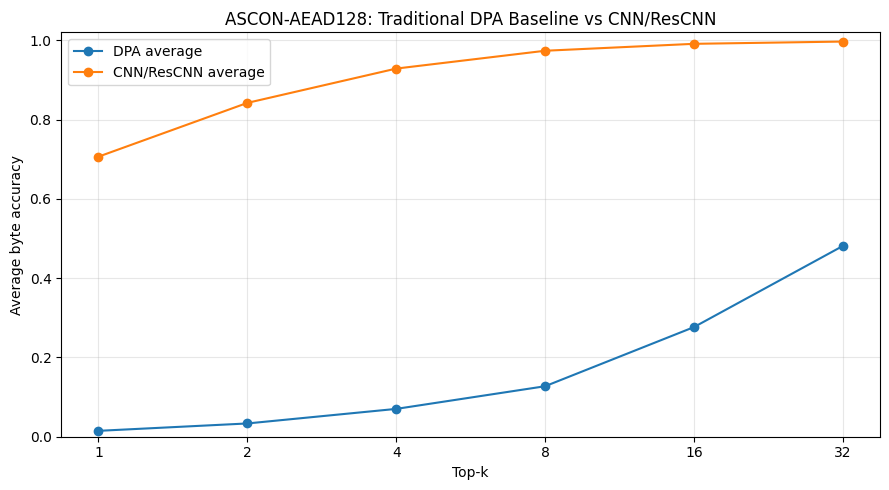

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\ascon_dpa_baseline\run_20260603_090037\ascon_dpa_vs_cnn_topk_comparison.png


In [13]:
# Cell 13 - Plot DPA vs CNN if comparison is available

if comparison_df is not None and len(comparison_df) > 0:
    plt.figure(figsize=(9, 5))
    plt.plot(comparison_df["topk"], comparison_df["dpa_avg"], marker="o", label="DPA average")
    plt.plot(comparison_df["topk"], comparison_df["cnn_avg"], marker="o", label="CNN/ResCNN average")
    plt.xscale("log", base=2)
    plt.xticks(TOPK_VALUES, [str(k) for k in TOPK_VALUES])
    plt.ylim(0, 1.02)
    plt.xlabel("Top-k")
    plt.ylabel("Average byte accuracy")
    plt.title("ASCON-AEAD128: Traditional DPA Baseline vs CNN/ResCNN")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plot_path = OUT_DIR / "ascon_dpa_vs_cnn_topk_comparison.png"
    plt.savefig(plot_path, dpi=160)
    plt.show()
    print("Saved:", plot_path)

## Interpretation guide

Use the DPA baseline as a traditional statistical method comparison:

```text
Traditional DPA baseline:
Difference-of-Means leakage curves per key bit → selected leakage points → bit-score combination → 256 byte candidates → Top-k accuracy
```

If CNN/ResCNN gives higher Top-k than DPA, then the conclusion is:

```text
The CNN/ResCNN attack provides stronger key-byte candidate ranking than the traditional DPA baseline.
```

If DPA also performs very well, the conclusion is still useful:

```text
The selected tight-trigger ASCON region contains strong exploitable key-byte leakage. The CNN/ResCNN method can then be evaluated based on whether it improves Top-k ranking, reduces candidate space more aggressively, or requires fewer traces.
```